In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns

### 1.2.Tasks to Understand the Dataset: auto_mpg.csv

In [2]:
df = pd.read_csv("auto_mpg.csv.csv")

<Axes: >

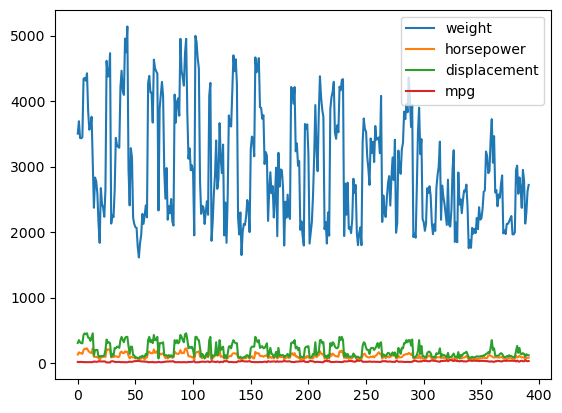

In [3]:
df.plot(kind='line')

<Axes: xlabel='weight', ylabel='mpg'>

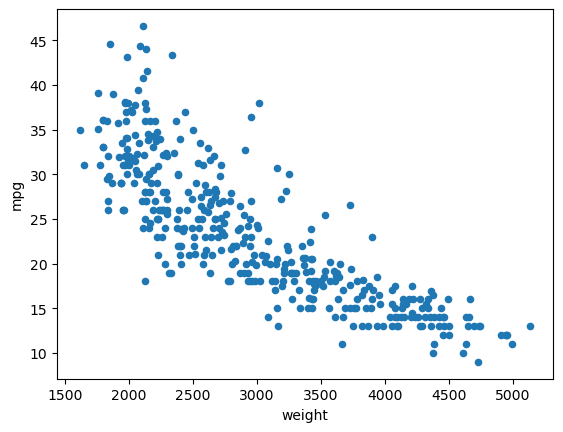

In [4]:
df.plot(kind='scatter', x='weight', y='mpg')

<Axes: xlabel='horsepower', ylabel='mpg'>

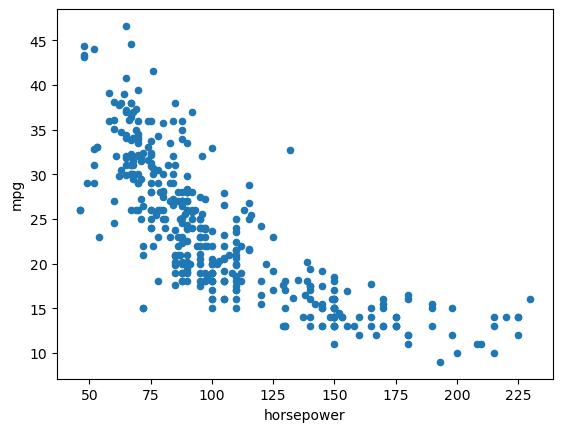

In [5]:
df.plot(kind='scatter', x='horsepower', y='mpg')

<Axes: xlabel='displacement', ylabel='mpg'>

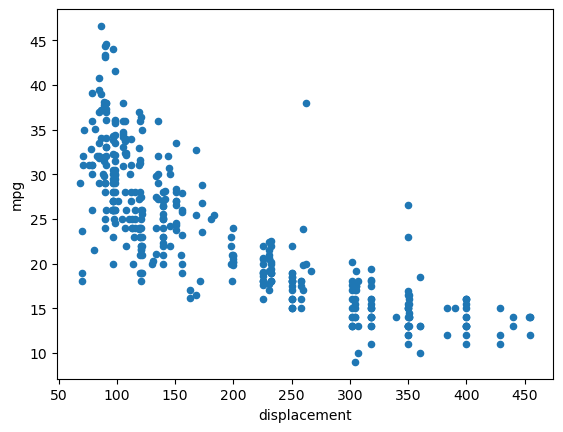

In [6]:
df.plot(kind='scatter', x='displacement', y='mpg')

In [7]:
df.shape    

(392, 4)

In [8]:
describe_df = df.describe()

print(tabulate(describe_df, headers="keys", tablefmt="grid"))

+-------+----------+--------------+----------------+-----------+
|       |   weight |   horsepower |   displacement |       mpg |
+=======+==========+==============+================+===========+
| count |  392     |     392      |        392     | 392       |
+-------+----------+--------------+----------------+-----------+
| mean  | 2977.58  |     104.469  |        194.412 |  23.4459  |
+-------+----------+--------------+----------------+-----------+
| std   |  849.403 |      38.4912 |        104.644 |   7.80501 |
+-------+----------+--------------+----------------+-----------+
| min   | 1613     |      46      |         68     |   9       |
+-------+----------+--------------+----------------+-----------+
| 25%   | 2225.25  |      75      |        105     |  17       |
+-------+----------+--------------+----------------+-----------+
| 50%   | 2803.5   |      93.5    |        151     |  22.75    |
+-------+----------+--------------+----------------+-----------+
| 75%   | 3614.75  |     

In [9]:
describe_df["mpg"]

count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [10]:
df.sample(8)

,weight,horsepower,displacement,mpg
353,2635.0,74.0,120.0,31.6
284,3725.0,129.0,302.0,17.6
248,3735.0,140.0,318.0,19.4
371,1970.0,68.0,91.0,31.0
176,2957.0,88.0,120.0,23.0
183,2255.0,79.0,98.0,26.0
263,4080.0,140.0,318.0,17.5
47,3139.0,88.0,250.0,18.0


In [11]:
df.notnull().sum()

weight          392
horsepower      392
displacement    392
mpg             392
dtype: int64

In [12]:
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   weight        392 non-null    float64
 1   horsepower    392 non-null    float64
 2   displacement  392 non-null    float64
 3   mpg           392 non-null    float64
dtypes: float64(4)
memory usage: 12.4 KB


In [13]:
print(tabulate(df.corr(),headers="keys", tablefmt="grid"))

+--------------+-----------+--------------+----------------+-----------+
|              |    weight |   horsepower |   displacement |       mpg |
+==============+===========+==============+================+===========+
| weight       |  1        |     0.864538 |       0.932994 | -0.832244 |
+--------------+-----------+--------------+----------------+-----------+
| horsepower   |  0.864538 |     1        |       0.897257 | -0.778427 |
+--------------+-----------+--------------+----------------+-----------+
| displacement |  0.932994 |     0.897257 |       1        | -0.805127 |
+--------------+-----------+--------------+----------------+-----------+
| mpg          | -0.832244 |    -0.778427 |      -0.805127 |  1        |
+--------------+-----------+--------------+----------------+-----------+


In [14]:
print(tabulate(df.cov(),headers="keys", tablefmt="grid"))

+--------------+-----------+--------------+----------------+------------+
|              |    weight |   horsepower |   displacement |        mpg |
+==============+===========+==============+================+============+
| weight       | 721485    |    28265.6   |      82929.1   | -5517.44   |
+--------------+-----------+--------------+----------------+------------+
| horsepower   |  28265.6  |     1481.57  |       3614.03  |  -233.858  |
+--------------+-----------+--------------+----------------+------------+
| displacement |  82929.1  |     3614.03  |      10950.4   |  -657.585  |
+--------------+-----------+--------------+----------------+------------+
| mpg          |  -5517.44 |     -233.858 |       -657.585 |    60.9181 |
+--------------+-----------+--------------+----------------+------------+


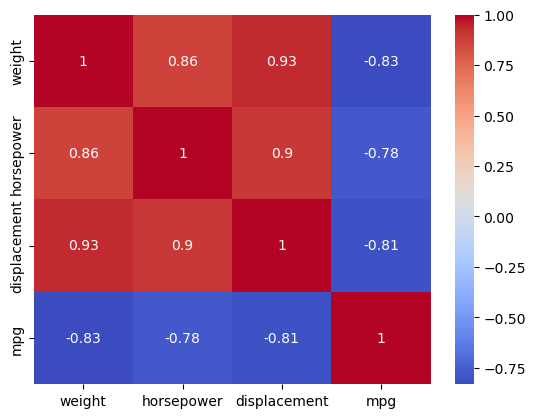

In [15]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

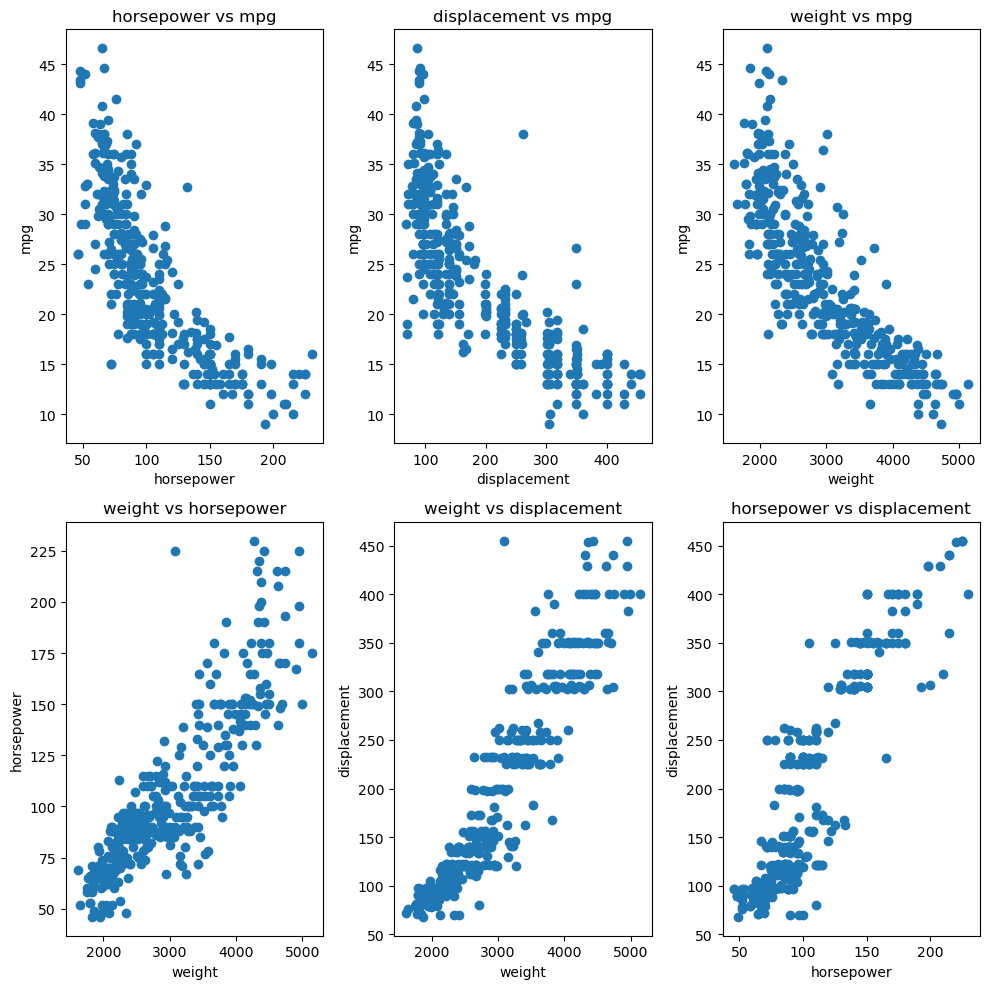

In [16]:
features = ["weight", "horsepower", "displacement", "mpg"]

fig, axs = plt.subplots(2, 3, figsize=(10, 10))

# pairs = [
#     ("weight", "horsepower"),
#     ("weight", "displacement"),
#     ("weight", "mpg"),
#     ("horsepower", "displacement"),
#     ("horsepower", "mpg"),
#     ("displacement", "mpg"),
#     ("horsepower", "weight"),
#     ("displacement", "weight"),
#     ("mpg", "weight")
# ]

pairs = [
    ("horsepower", "mpg"),
    ("displacement", "mpg"),
    ("weight", "mpg"),
    ("weight", "horsepower"),
    ("weight", "displacement"),
    ("horsepower", "displacement"),
]



for ax, (x, y) in zip(axs.flatten(), pairs):
    ax.scatter(df[x], df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

### Creating the Model: Simple Linear Regression

Mean Absolute Error: 3.4641211922147592
Mean Squared Error: 17.693388269545686
Root Mean Squared Error: 4.206350944648542

Learned parameters:
Theta0 (intercept) = 47.200526427552106
Theta1 (slope)     = -0.007903610385225605
number of train samples: 313
number of test samples: 79


/home/mehdi/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


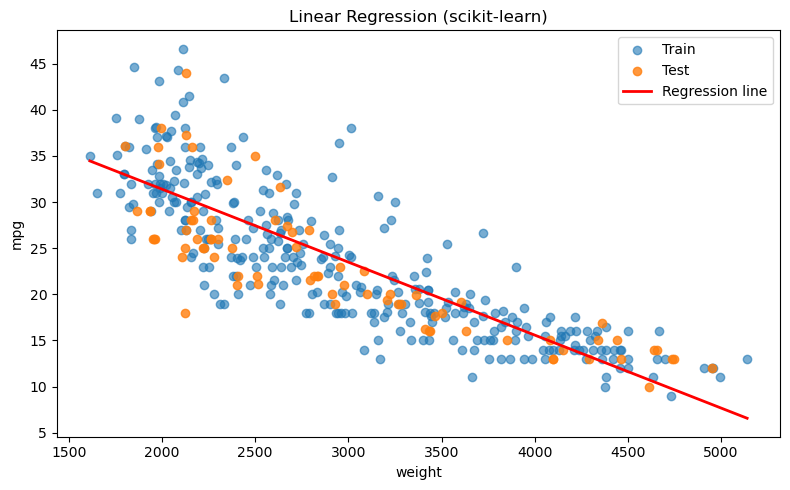

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# ----------------------------
# Data
# ----------------------------
X = df[["weight"]]
Y = df[["mpg"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

# ----------------------------
# Train model
# ----------------------------
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# ----------------------------
# Predictions
# ----------------------------
predictions = regressor.predict(X_test)

# ----------------------------
# Metrics
# ----------------------------
print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, predictions))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, predictions))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

# ----------------------------
# Print thetas
# ----------------------------
theta0 = regressor.intercept_[0]
theta1 = regressor.coef_[0][0]

print("\nLearned parameters:")
print(f"Theta0 (intercept) = {theta0}")
print(f"Theta1 (slope)     = {theta1}")

print("number of train samples:", len(X_train))
print("number of test samples:", len(X_test))

# ----------------------------
# Regression line
# ----------------------------
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = regressor.predict(x_line)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label="Train")
plt.scatter(X_test, y_test, alpha=0.8, label="Test")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression line")

plt.xlabel("weight")
plt.ylabel("mpg")
plt.title("Linear Regression (scikit-learn)")
plt.legend()
plt.tight_layout()
plt.show()


number of train samples: 313
number of test samples: 79
Mean Absolute Error: 3.4641211922147823
Mean Squared Error: 17.693388269545835
Root Mean Squared Error: 4.20635094464856

Learned parameters (from scratch):
Theta0 (intercept) = 47.20052642755218
Theta1 (slope)     = -0.007903610385225607


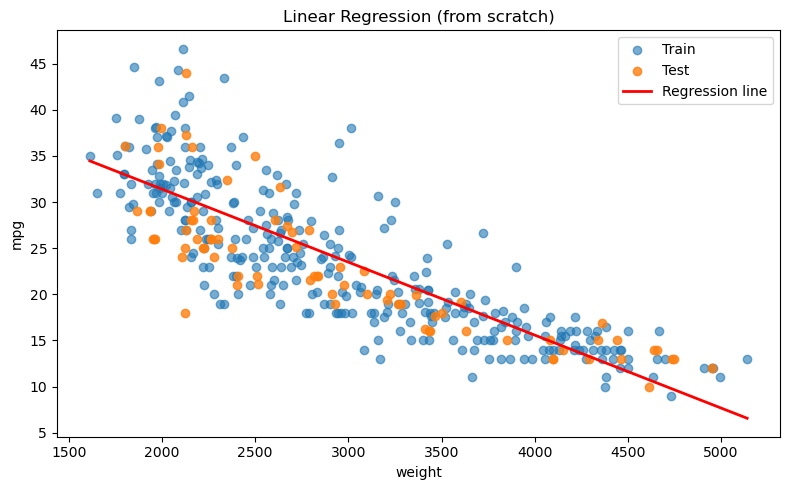

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ----------------------------
# 1) Prepare data
# ----------------------------
X = df[["weight"]].to_numpy(dtype=float)  # (n,1)
y = df[["mpg"]].to_numpy(dtype=float)     # (n,1)

# ----------------------------
# 2) SAME split as sklearn
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("number of train samples:", len(X_train))
print("number of test samples:", len(X_test))

# ----------------------------
# 3) Add bias term (intercept)
# ----------------------------
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b  = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ----------------------------
# 4) Linear Regression (Normal Equation)
# ----------------------------
theta = np.linalg.inv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train)

# ----------------------------
# 5) Predictions
# ----------------------------
y_pred = X_test_b @ theta

# ----------------------------
# 6) Metrics
# ----------------------------
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

# ----------------------------
# 7) Print thetas
# ----------------------------
theta0 = theta[0, 0]   # intercept
theta1 = theta[1, 0]   # slope

print("\nLearned parameters (from scratch):")
print(f"Theta0 (intercept) = {theta0}")
print(f"Theta1 (slope)     = {theta1}")

# ----------------------------
# 8) Regression line
# ----------------------------
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
x_line_b = np.c_[np.ones((x_line.shape[0], 1)), x_line]
y_line = x_line_b @ theta

# ----------------------------
# 9) Plot
# ----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label="Train")
plt.scatter(X_test, y_test, alpha=0.8, label="Test")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression line")

plt.xlabel("weight")
plt.ylabel("mpg")
plt.title("Linear Regression (from scratch)")
plt.legend()
plt.tight_layout()
plt.show()


Mean Absolute Error: 3.299995522821914
Mean Squared Error: 16.719639563330592
Root Mean Squared Error: 4.088965585980223


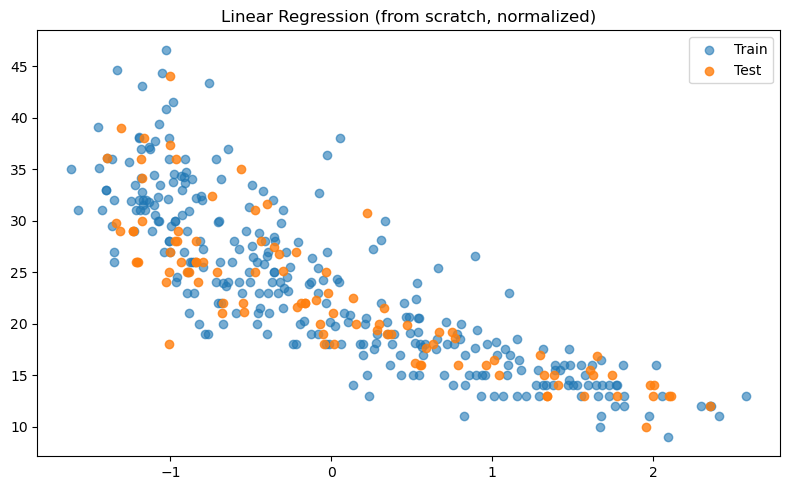

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ----------------------------
# 1) Prepare data
# ----------------------------
X = df[["weight"]].to_numpy(dtype=float)   # (n,1)
y = df[["mpg"]].to_numpy(dtype=float)      # (n,1)

# ----------------------------
# 2) SAME split as sklearn
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ----------------------------
# 3) Normalize (STANDARDIZATION)
#    use TRAIN stats only
# ----------------------------
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

# ----------------------------
# 4) Add bias term (intercept)
# ----------------------------
X_train_b = np.c_[np.ones((X_train_norm.shape[0], 1)), X_train_norm]
X_test_b  = np.c_[np.ones((X_test_norm.shape[0], 1)), X_test_norm]

# ----------------------------
# 5) Linear Regression (Normal Equation)
# ----------------------------
theta = np.linalg.inv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train)

# ----------------------------
# 6) Predict
# ----------------------------
y_pred = X_test_b @ theta

# ----------------------------
# 7) Metrics
# ----------------------------
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

# ----------------------------
# 8) Plot
# ----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(X_train_norm, y_train, alpha=0.6, label="Train")
plt.scatter(X_test_norm, y_test, alpha=0.8, label="Test")
plt.title("Linear Regression (from scratch, normalized)")
plt.legend()
plt.tight_layout()
plt.show()


===== Batch GD Results =====
lr=0.01, iters=2000, standardized_X=True
MAE : 3.2999955228218822
MSE : 16.71963956333041
RMSE: 4.088965585980201

Learned parameters (on used X scale):
Theta0 = 23.692176870748213
Theta1 = -6.6708018113406835

Equivalent line on original X scale:
mpg = 47.28325313862034 + -0.007938232270314226 * weight


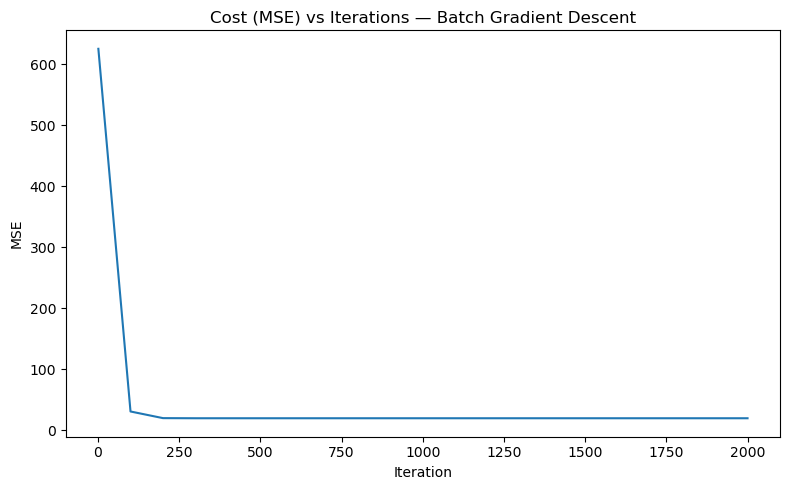

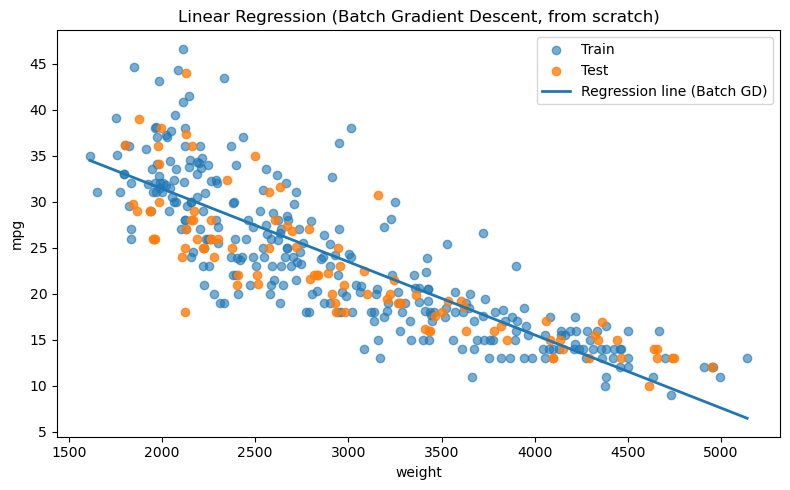

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================================
# Batch Gradient Descent (from scratch)
# - same train/test split
# - optional feature standardization (recommended)
# - prints thetas (theta0, theta1)
# - plots MSE vs iterations (recorded every 100 iters)
# - plots regression line + train/test samples
# ============================================================

# ----------------------------
# 1) Prepare data
# ----------------------------
X = df[["weight"]].to_numpy(dtype=float)  # (n,1)
y = df[["mpg"]].to_numpy(dtype=float)     # (n,1)

# ----------------------------
# 2) SAME split as sklearn
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ----------------------------
# 3) Standardize X using TRAIN stats only (set to False if you don't want)
# ----------------------------
USE_STANDARDIZE = True

if USE_STANDARDIZE:
    X_mean = X_train.mean(axis=0)
    X_std  = X_train.std(axis=0)
    X_train_use = (X_train - X_mean) / X_std
    X_test_use  = (X_test  - X_mean) / X_std
else:
    X_train_use = X_train
    X_test_use  = X_test

# ----------------------------
# 4) Add bias term (intercept)
# ----------------------------
X_train_b = np.c_[np.ones((X_train_use.shape[0], 1)), X_train_use]  # (m,2)
X_test_b  = np.c_[np.ones((X_test_use.shape[0], 1)),  X_test_use]   # (k,2)

# ----------------------------
# 5) Batch Gradient Descent
# ----------------------------
def batch_gd(Xb, y, lr=0.05, iters=2000, log_every=100):
    """
    Xb: (m,2) [1, x] already includes bias column
    y : (m,1)
    """
    m, d = Xb.shape
    theta = np.zeros((d, 1))
    it_hist, mse_hist = [], []

    for t in range(1, iters + 1):
        y_pred = Xb @ theta
        err = y_pred - y
        grad = (2/m) * (Xb.T @ err)          # batch gradient (all samples)
        theta = theta - lr * grad

        if t == 1 or t % log_every == 0 or t == iters:
            it_hist.append(t)
            mse_hist.append(float(np.mean(err**2)))

    return theta, np.array(it_hist), np.array(mse_hist)

# Try a learning rate / iterations (change these to experiment)
lr = 0.01
iters = 2000

theta_gd, it_hist, mse_hist = batch_gd(X_train_b, y_train, lr=lr, iters=iters, log_every=100)

# ----------------------------
# 6) Predictions + Metrics
# ----------------------------
y_pred_test = X_test_b @ theta_gd

mae = np.mean(np.abs(y_test - y_pred_test))
mse = np.mean((y_test - y_pred_test) ** 2)
rmse = np.sqrt(mse)

print("===== Batch GD Results =====")
print(f"lr={lr}, iters={iters}, standardized_X={USE_STANDARDIZE}")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

# ----------------------------
# 7) Print thetas (theta0, theta1)
#    If standardized, also print equivalent line in original weight scale
# ----------------------------
theta0 = float(theta_gd[0, 0])
theta1 = float(theta_gd[1, 0])

print("\nLearned parameters (on used X scale):")
print(f"Theta0 = {theta0}")
print(f"Theta1 = {theta1}")

if USE_STANDARDIZE:
    # y = theta0 + theta1 * ((x - mean)/std)
    # => y = (theta0 - theta1*mean/std) + (theta1/std)*x
    b0 = theta0 - theta1 * (X_mean[0] / X_std[0])
    b1 = theta1 / X_std[0]
    print("\nEquivalent line on original X scale:")
    print(f"mpg = {b0} + {b1} * weight")
else:
    b0, b1 = theta0, theta1

# ----------------------------
# 8) Plot: Cost (MSE) vs Iterations (recorded every 100)
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(it_hist, mse_hist)
plt.title("Cost (MSE) vs Iterations — Batch Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

# ----------------------------
# 9) Plot: Regression line + Train/Test samples (original scale)
# ----------------------------
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = b0 + b1 * x_line

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label="Train")
plt.scatter(X_test,  y_test,  alpha=0.8, label="Test")
plt.plot(x_line, y_line, linewidth=2, label="Regression line (Batch GD)")

plt.xlabel("weight")
plt.ylabel("mpg")
plt.title("Linear Regression (Batch Gradient Descent, from scratch)")
plt.legend()
plt.tight_layout()
plt.show()


# A) Batch Gradient Descent (BGD)

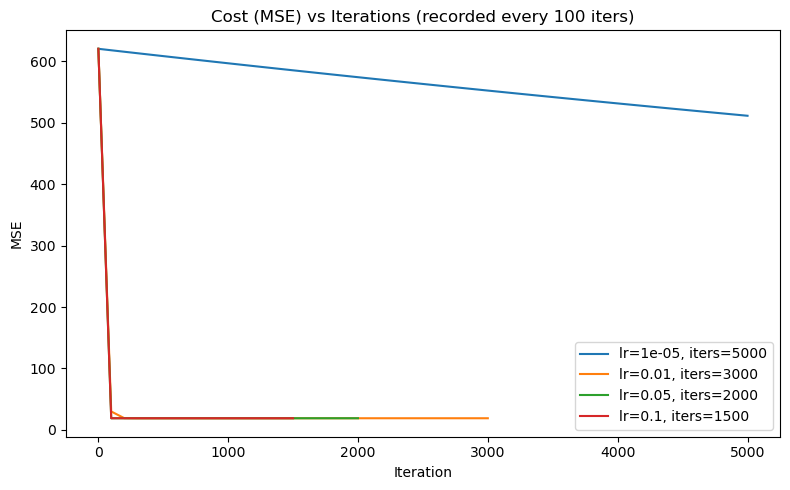

===== Experiments Summary (GD on normalized X) =====

[lr=1e-05, iters=5000]
  theta0 = 2.245797, theta1 = -0.631635
  Train MSE = 511.088597
  Test  MSE = 466.308836

[lr=0.01, iters=3000]
  theta0 = 23.599361, theta1 = -6.637367
  Train MSE = 19.045106
  Test  MSE = 17.693388

[lr=0.05, iters=2000]
  theta0 = 23.599361, theta1 = -6.637367
  Train MSE = 19.045106
  Test  MSE = 17.693388

[lr=0.1, iters=1500]
  theta0 = 23.599361, theta1 = -6.637367
  Train MSE = 19.045106
  Test  MSE = 17.693388

===== Typical Observations =====
- Smaller learning rate: more stable but slower convergence (needs more iterations).
- Larger learning rate: converges faster, but if too large it may oscillate/diverge (MSE increases).
- More iterations: helps until the cost plateaus; after that improvements are tiny.

===== Best Model (by lowest Test MSE) =====
Best config: lr=0.01, iters=3000
Learned parameters (on normalized X):
  theta0 = 23.599361
  theta1 = -6.637367

Equivalent line on original X (weig

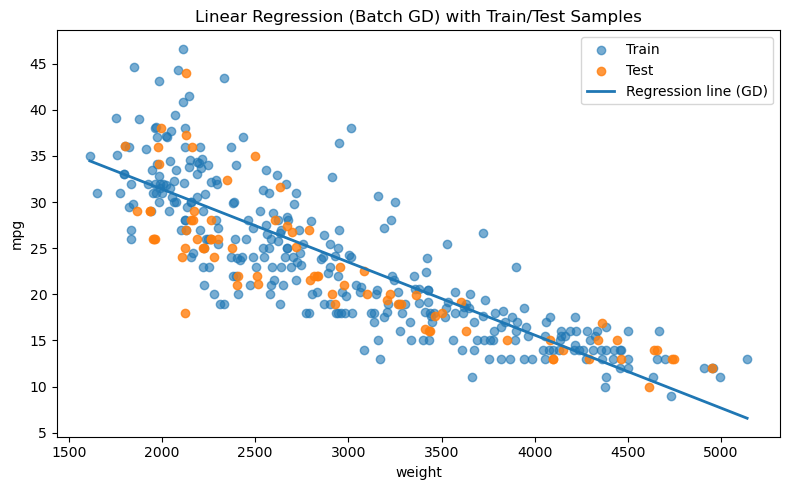

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================================
# 1) Data prep + split
# ============================================================
X = df[["weight"]].to_numpy(dtype=float)   # (n,1)
y = df[["mpg"]].to_numpy(dtype=float)      # (n,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Normalize X using TRAIN stats only (recommended for GD)
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_n = (X_train - X_mean) / X_std
X_test_n  = (X_test  - X_mean) / X_std

# Add bias column
X_train_b = np.c_[np.ones((X_train_n.shape[0], 1)), X_train_n]  # (m,2)
X_test_b  = np.c_[np.ones((X_test_n.shape[0], 1)),  X_test_n]   # (k,2)

# ============================================================
# 2) Batch Gradient Descent (Linear Regression)
#    - records MSE every `log_every` iterations
# ============================================================
def mse_cost(Xb, y, theta):
    err = Xb @ theta - y
    return float(np.mean(err**2))

def batch_gd_linear_regression(Xb, y, lr=0.05, iters=2000, log_every=100):
    m, d = Xb.shape
    theta = np.zeros((d, 1))  # [theta0, theta1]^T
    cost_hist = []            # costs recorded every log_every
    iter_hist = []            # iteration indices for those costs

    for t in range(1, iters + 1):
        y_pred = Xb @ theta
        err = y_pred - y
        grad = (2/m) * (Xb.T @ err)         # Batch gradient uses ALL samples
        theta = theta - lr * grad

        if (t % log_every) == 0 or t == 1 or t == iters:
            cost_hist.append(float(np.mean(err**2)))
            iter_hist.append(t)

    return theta, np.array(iter_hist), np.array(cost_hist)

# ============================================================
# 3) Experiment with different learning rates + iterations
# ============================================================
configs = [
    {"lr": 0.00001, "iters": 5000},
    {"lr": 0.01,  "iters": 3000},
    {"lr": 0.05,  "iters": 2000},
    {"lr": 0.1,   "iters": 1500},
]

results = []

plt.figure(figsize=(8, 5))
for cfg in configs:
    theta, it_hist, cost_hist = batch_gd_linear_regression(
        X_train_b, y_train, lr=cfg["lr"], iters=cfg["iters"], log_every=100
    )

    train_mse = mse_cost(X_train_b, y_train, theta)
    test_mse  = mse_cost(X_test_b,  y_test,  theta)

    results.append({
        "lr": cfg["lr"],
        "iters": cfg["iters"],
        "theta0": float(theta[0, 0]),
        "theta1": float(theta[1, 0]),
        "train_mse": train_mse,
        "test_mse": test_mse,
        "theta": theta
    })

    plt.plot(it_hist, cost_hist, label=f"lr={cfg['lr']}, iters={cfg['iters']}")

plt.title("Cost (MSE) vs Iterations (recorded every 100 iters)")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

# Print experiment observations + parameters
print("===== Experiments Summary (GD on normalized X) =====")
for r in results:
    print(f"\n[lr={r['lr']}, iters={r['iters']}]")
    print(f"  theta0 = {r['theta0']:.6f}, theta1 = {r['theta1']:.6f}")
    print(f"  Train MSE = {r['train_mse']:.6f}")
    print(f"  Test  MSE = {r['test_mse']:.6f}")

print("\n===== Typical Observations =====")
print("- Smaller learning rate: more stable but slower convergence (needs more iterations).")
print("- Larger learning rate: converges faster, but if too large it may oscillate/diverge (MSE increases).")
print("- More iterations: helps until the cost plateaus; after that improvements are tiny.")

# ============================================================
# 4) Choose the best model (lowest Test MSE) and report theta0, theta1
# ============================================================
best = min(results, key=lambda r: r["test_mse"])
theta_best = best["theta"]

theta0 = float(theta_best[0, 0])
theta1 = float(theta_best[1, 0])

print("\n===== Best Model (by lowest Test MSE) =====")
print(f"Best config: lr={best['lr']}, iters={best['iters']}")
print(f"Learned parameters (on normalized X):")
print(f"  theta0 = {theta0:.6f}")
print(f"  theta1 = {theta1:.6f}")

# Convert to ORIGINAL (unnormalized weight scale) so you can plot a line on raw X:
# y = theta0 + theta1 * ((x - mean)/std)
# => y = (theta0 - theta1*mean/std) + (theta1/std)*x
b0 = theta0 - theta1 * (X_mean[0] / X_std[0])
b1 = theta1 / X_std[0]
print("\nEquivalent line on original X (weight) scale:")
print(f"  mpg = {b0:.6f} + {b1:.6f} * weight")

# ============================================================
# 5) Plot regression line with training + testing samples (original scale)
# ============================================================
# Line over the full range of weights
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = b0 + b1 * x_line

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label="Train")
plt.scatter(X_test,  y_test,  alpha=0.8, label="Test")
plt.plot(x_line, y_line, linewidth=2, label="Regression line (GD)")
plt.title("Linear Regression (Batch GD) with Train/Test Samples")
plt.xlabel("weight")
plt.ylabel("mpg")
plt.legend()
plt.tight_layout()
plt.show()


# B)Stochastic Gradient Descent (SGD)

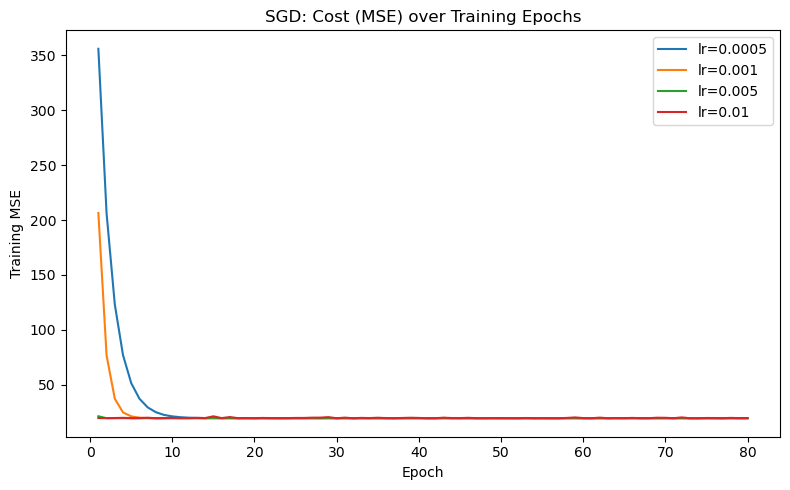

===== SGD Experiments Summary (normalized X) =====

[lr=0.0005, epochs=80]
  theta0 = 23.695928, theta1 = -6.669124
  Train MSE = 19.463794
  Test  MSE = 16.722352

[lr=0.001, epochs=80]
  theta0 = 23.708241, theta1 = -6.665922
  Train MSE = 19.464059
  Test  MSE = 16.736035

[lr=0.005, epochs=80]
  theta0 = 23.744455, theta1 = -6.503194
  Train MSE = 19.494603
  Test  MSE = 16.504799

[lr=0.01, epochs=80]
  theta0 = 23.749815, theta1 = -6.223151
  Train MSE = 19.667491
  Test  MSE = 16.145391

===== Learning-rate Effect (discussion) =====
- Too small lr: very slow decrease in cost (may look almost flat).
- Good lr: cost decreases quickly, then fluctuates slightly around a minimum (SGD is noisy).
- Too large lr: cost oscillates heavily or diverges (MSE increases or becomes unstable).

===== Best SGD Model (by lowest Test MSE) =====
Best config: lr=0.01, epochs=80
Learned parameters (on normalized X):
  theta0 = 23.749815
  theta1 = -6.223151

Equivalent line on original X (weight) scal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================================
# Shared: data, split, normalization (same as Batch GD)
# ============================================================
X = df[["weight"]].to_numpy(dtype=float)   # (n,1)
y = df[["mpg"]].to_numpy(dtype=float)      # (n,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Normalize X using TRAIN stats only (same as Batch GD)
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_n = (X_train - X_mean) / X_std
X_test_n  = (X_test  - X_mean) / X_std

# Add bias column
X_train_b = np.c_[np.ones((X_train_n.shape[0], 1)), X_train_n]  # (m,2)
X_test_b  = np.c_[np.ones((X_test_n.shape[0], 1)),  X_test_n]   # (k,2)

def mse_cost(Xb, y, theta):
    err = Xb @ theta - y
    return float(np.mean(err**2))

# ============================================================
# B) Stochastic Gradient Descent (SGD)
# 1) Update parameters after EACH sample
# 2) Same train set + same normalization as Batch GD
# 3) Plot cost (MSE) over epochs
# ============================================================
def sgd_linear_regression(Xb, y, lr=0.01, epochs=50, shuffle=True, seed=42):
    """
    SGD for linear regression with MSE.
    - Updates theta after each sample.
    - Records training MSE at end of each epoch.
    """
    rng = np.random.default_rng(seed)
    m, d = Xb.shape
    theta = np.zeros((d, 1))
    epoch_costs = []

    for ep in range(epochs):
        if shuffle:
            idx = rng.permutation(m)
        else:
            idx = np.arange(m)

        for i in idx:
            xi = Xb[i:i+1, :]           # (1,d)
            yi = y[i:i+1, :]            # (1,1)

            y_pred_i = xi @ theta       # (1,1)
            err_i = y_pred_i - yi       # (1,1)

            # Gradient for single sample: 2 * x_i^T * (x_i theta - y_i)
            grad_i = 2.0 * (xi.T @ err_i)  # (d,1)
            theta = theta - lr * grad_i

        # cost at end of epoch (over full training set)
        epoch_costs.append(mse_cost(Xb, y, theta))

    return theta, np.array(epoch_costs)

# ============================================================
# 4) Experiment with different learning rates
# ============================================================
sgd_configs = [
    {"lr": 0.0005, "epochs": 80},
    {"lr": 0.001,  "epochs": 80},
    {"lr": 0.005,  "epochs": 80},
    {"lr": 0.01,   "epochs": 80},
]

sgd_results = []

plt.figure(figsize=(8, 5))
for cfg in sgd_configs:
    theta_sgd, costs = sgd_linear_regression(
        X_train_b, y_train, lr=cfg["lr"], epochs=cfg["epochs"], shuffle=True, seed=42
    )

    train_mse = mse_cost(X_train_b, y_train, theta_sgd)
    test_mse  = mse_cost(X_test_b,  y_test,  theta_sgd)

    theta0 = float(theta_sgd[0, 0])
    theta1 = float(theta_sgd[1, 0])

    sgd_results.append({
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "theta0": theta0,
        "theta1": theta1,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "theta": theta_sgd,
        "costs": costs
    })

    plt.plot(np.arange(1, cfg["epochs"] + 1), costs, label=f"lr={cfg['lr']}")

plt.title("SGD: Cost (MSE) over Training Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.legend()
plt.tight_layout()
plt.show()

# Print learning-rate effects + parameters
print("===== SGD Experiments Summary (normalized X) =====")
for r in sgd_results:
    print(f"\n[lr={r['lr']}, epochs={r['epochs']}]")
    print(f"  theta0 = {r['theta0']:.6f}, theta1 = {r['theta1']:.6f}")
    print(f"  Train MSE = {r['train_mse']:.6f}")
    print(f"  Test  MSE = {r['test_mse']:.6f}")

print("\n===== Learning-rate Effect (discussion) =====")
print("- Too small lr: very slow decrease in cost (may look almost flat).")
print("- Good lr: cost decreases quickly, then fluctuates slightly around a minimum (SGD is noisy).")
print("- Too large lr: cost oscillates heavily or diverges (MSE increases or becomes unstable).")

# ============================================================
# 5) Report learned theta0, theta1 for the best SGD model (lowest Test MSE)
# ============================================================
best_sgd = min(sgd_results, key=lambda r: r["test_mse"])
theta_best = best_sgd["theta"]
theta0_best = float(theta_best[0, 0])
theta1_best = float(theta_best[1, 0])

print("\n===== Best SGD Model (by lowest Test MSE) =====")
print(f"Best config: lr={best_sgd['lr']}, epochs={best_sgd['epochs']}")
print("Learned parameters (on normalized X):")
print(f"  theta0 = {theta0_best:.6f}")
print(f"  theta1 = {theta1_best:.6f}")

# Optional: convert to original weight scale (useful for interpretation/plotting)
b0 = theta0_best - theta1_best * (X_mean[0] / X_std[0])
b1 = theta1_best / X_std[0]
print("\nEquivalent line on original X (weight) scale:")
print(f"  mpg = {b0:.6f} + {b1:.6f} * weight")

